### Hemispheric Asymmetry of Tau Pathology is Related to Asymmetric Amyloid Deposition in Alzheimer’s Disease

Toomas Erik Anijärv

05/08/2025

#### table of contents

1. study sample selection
2. healthy controls selection and normative connectivity masks
3. association between connectivity and tau laterality
4. cross-sectional association between Ab and tau lateralities
5. cross-sectional association between Ab and tau lateralities (in external cohorts)
6. cross-sectional association between Ab and tau lateralities (sensitivity analyses)
7. **longitudinal association between Ab and tau lateralities** *[this notebook]*
8. longitudinal association between Ab and tau lateralities (sensitivity analyses)
9. asymmetrical PET cases
10. network based statistics (three parts)
10. sampled iterative local approximation  (three parts)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import patsy
from scipy.stats import zscore
import tableone as tb
import warnings

warnings.simplefilter(action='ignore')

from src.connectomics.atlases import get_dk_rois
from src.analysis.misc import set_plot_style

set_plot_style(dpi=150)
ROIs = get_dk_rois()

# in
data_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
df_dir = os.path.join(data_dir, 'datasets')

# out
media_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'media'))

plot_dir = os.path.join(media_dir, '_plots')
os.makedirs(plot_dir, exist_ok=True)

#### **Results:** Higher baseline Aβ laterality is associated with increased tau laterality over time 

To further investigate the impact of baseline Aβ laterality on longitudinal change in tau laterality, we examined a subsample of 289 A+ subjects from the original cohort of 837 who underwent at least one Aβ-PET scan and additionally had available longitudinal tau-PET scans (range of timepoints = 2-5; average follow-up = 2.9 years). 

In [2]:
# LONG
ld_grp_col = 'tau_positive_bas'
amy_prefix = 'fnc'
tau_prefix = 'tnic'

df_ld = pd.read_csv(os.path.join(df_dir, f'bf2_tau_asymmetry_ad_long_{tau_prefix}_{amy_prefix}.csv'), low_memory=False, index_col=0)
df_ld['apoe4_count'] = df_ld['apoe_genotype_baseline_variable'].astype(str).apply(lambda x: np.nan if x is np.nan else sum(int(i == '4') for i in x))
# df_ld['gender_baseline_variable'] = df_ld['gender_baseline_variable'].map({0.0: 'M', 1.0: 'F'})

# sort by id and age
df_ld = df_ld.sort_values(['mid', 'age'])

# drop timepoints which dont have tau data and subjects with not multiple timepoints
df_ld = df_ld.dropna(subset='tnic_temporal_meta')
df_ld = df_ld[df_ld.groupby('mid')['mid'].transform('count') > 1]

# subjects who have more than 3 timepoints, in case the first timepoint doesnt have amyPET, set the second timepoint as first if that one has
def adjust_timepoints(group, column, min_length=3):
    if pd.isna(group.iloc[0][column]):
        if len(group) >= min_length:
            if pd.notna(group.iloc[1][column]):
                group = group.iloc[1:].reset_index(drop=True)
    return group
df_ld = df_ld.groupby('mid', as_index=False, group_keys=False).apply(lambda x: adjust_timepoints(x, 'fnc_global')).reset_index(drop=True)
print(f"N (multiple tau-PET scans) = {len(df_ld['mid'].unique())} (all timepoints = {len(df_ld)})")

# df with available baseline amyPET
df_ld_a = df_ld[df_ld.groupby('mid')['fnc_global'].transform(lambda x: x.iloc[0]).notna()]
print(f"N (has baseline amy-PET) = {len(df_ld_a['mid'].unique())} (all timepoints = {len(df_ld_a)})")

# set baseline values for all timepoints
df_ld_a[ld_grp_col] = df_ld_a.groupby('mid')['tau_positive'].transform(lambda x: x.iloc[0])
df_ld_a['time'] = df_ld_a.groupby('mid')['age'].transform(lambda x: x - x.iloc[0])
df_ld_a['age_bas'] = df_ld_a.groupby('mid')['age'].transform(lambda x: x.iloc[0])
df_ld_a['fnc_global_bas'] = df_ld_a.groupby('mid')['fnc_global'].transform(lambda x: x.iloc[0])
df_ld_a['tnic_temporal_meta_bas'] = df_ld_a.groupby('mid')['tnic_temporal_meta'].transform(lambda x: x.iloc[0])

# add the amount of timepoints for tau PET and if has amyloid PET at a timepoint
df_ld_a['tp_total'] = df_ld_a.groupby('mid')['mid'].transform('count')
df_ld_a['tp_tauPET'] = df_ld_a.groupby('mid')['tnic_temporal_meta'].transform(lambda x: x.notna().sum())
df_ld_a['has_amyPET'] = df_ld_a.groupby('mid')['fnc_global_bas'].transform(lambda x: x.notna().astype(int))

# divide to tau positive and negative samples
df_ld_a_tneg = df_ld_a[df_ld_a[ld_grp_col]==False]
df_ld_a_tpos = df_ld_a[df_ld_a[ld_grp_col]==True]

df_ld_a_tnegpos = df_ld_a_tneg.groupby('mid').filter(lambda x: x['tau_positive'].iloc[1:].any())
df_ld_a_tnegneg = df_ld_a_tneg.groupby('mid').filter(lambda x: ~x['tau_positive'].any())

plots_rois_dict = {
    'A+': {
        'df': df_ld_a, 
        'rois': {
            'global': 'Global', 
        }
    },
    'A+T-': {
        'df': df_ld_a_tneg, 
        'rois': {
            'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI'
        }
    },
    'A+T+': {
        'df': df_ld_a_tpos, 
        'rois': {
            'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI'
        }
    },
    'A+T- to A+T-': {
        'df': df_ld_a_tnegneg, 
        'rois': {
            'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI'
        }
    },
    'A+T- to A+T+': {
        'df': df_ld_a_tnegpos, 
        'rois': {
            'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI'
        }
    }
}

for grp, g_data in plots_rois_dict.items():
    df_ = g_data['df']
    print(f"N ({grp}) = {len(df_['mid'].unique())} (all timepoints = {len(df_)})")

# print(f"N (multiple tau-PET) = {len(df_ld_bas)} (all timepoints = {len(df_ld)})")
# # first timepoints only
# df_ld_bas = df_ld.drop_duplicates(subset='mid', keep='first')
# print(f"N (multiple tau-PET) = {len(df_ld_bas)} (all timepoints = {len(df_ld)})")
# df_ld_a_bas = df_ld_a.drop_duplicates(subset='mid', keep='first')
# print(f"N (multiple tau-PET + baseline amy-PET) = {len(df_ld_a_bas)} (all timepoints = {len(df_ld_a)})")

N (multiple tau-PET scans) = 402 (all timepoints = 949)
N (has baseline amy-PET) = 289 (all timepoints = 707)
N (A+) = 289 (all timepoints = 707)
N (A+T-) = 180 (all timepoints = 452)
N (A+T+) = 109 (all timepoints = 255)
N (A+T- to A+T-) = 142 (all timepoints = 347)
N (A+T- to A+T+) = 38 (all timepoints = 105)


In [3]:
df_ld_a_bas = df_ld_a.drop_duplicates(subset='mid', keep='first')
print(f"N (longitudinal A+ with Ab-PET) = {len(df_ld_a_bas)} (all timepoints = {len(df_ld_a)})")

df_ld_a_bas['gender_baseline_variable'] = df_ld_a_bas['gender_baseline_variable'].map({0.0: 'M', 1.0: 'F'})

var_order = ['tp_tauPET', 'age', 'gender_baseline_variable', 'education_level_years_baseline_variable', 'diagnosis_baseline_variable', 
             'tnic_temporal_meta', 'tnic_temporal_meta_LI', 'fnc_global', 'apoe4_count', 'mmse_score', 'mPACC_v2']
var_cont = ['age', 'education_level_years_baseline_variable', 'tnic_temporal_meta', 'tnic_temporal_meta_LI', 'fnc_global', 
            'mmse_score', 'mPACC_v2']
var_cat = ['gender_baseline_variable', 'diagnosis_baseline_variable', 'apoe4_count', 'tp_tauPET']
var_notnorm = ['tnic_temporal_meta', 'tnic_temporal_meta_LI' 'fnc_global', 'mmse_score', 'mPACC_v2']
cat_order = {'gender_baseline_variable': ['M', 'F'], 'diagnosis_baseline_variable': ['Normal', 'SCD', 'MCI', 'AD'], 
                'apoe4_count': ['0', '1', '2']}
rename_vars = {'age': 'Age', 'gender_baseline_variable': 'Sex', 'education_level_years_baseline_variable': 'Education years',
               'diagnosis_baseline_variable': 'Diagnosis', 'tnic_temporal_meta': 'Temporal tau load', 
               'tnic_temporal_meta_LI' : 'Temporal tau laterality index', 'fnc_global': 'Global Aβ load', 
               'apoe4_count': 'ApoE4 count', 'mmse_score': 'MMSE', 'mPACC_v2': 'mPACC'}

table = tb.TableOne(
    data=df_ld_a_bas.copy(),
    groupby=ld_grp_col, columns=var_order, categorical=var_cat, continuous=var_cont, include_null=True, # data
    rename=rename_vars, label_suffix=True, decimals=2, missing=True, overall=False, order=cat_order, # visual
    dip_test=True, normal_test=True, tukey_test=True, nonnormal=var_notnorm, htest_name=True, pval=True, pval_adjust=None, # stats
)

display(table)
table.to_excel(os.path.join(media_dir, 'ld_demographics.xlsx'))

N (longitudinal A+ with Ab-PET) = 289 (all timepoints = 707)


Grouped by tau_positive_bas                                                                                             
                                                                    Missing                False                 True P-Value                                       Test
n                                                                                            180                  109                                                   
tp_tauPET, n (%)                         2                                           107 (59.44)           78 (71.56)   0.178  Chi-squared (warning: expected count < 5)
                                         3                                            55 (30.56)           25 (22.94)                                                   
                                         4                                             17 (9.44)             6 (5.50)                                                   
                                         5                                              1 (0.56)                                                                        
Age, mean (SD)                                                            0         73.09 (7.89)         72.08 (7.06)   0.264                          Two Sample T-test
Sex, n (%)                               M                                            92 (51.11)           57 (52.29)   0.941                                Chi-squared
                                         F                                            88 (48.89)           52 (47.71)                                                   
Education years, mean (SD)                                                4         12.78 (4.08)         12.98 (3.68)   0.670                          Two Sample T-test
Diagnosis, n (%)                         Normal                                       61 (33.89)           13 (11.93)  <0.001  Chi-squared (warning: expected count < 5)
                                         SCD                                          55 (30.56)           23 (21.10)                                                   
                                         MCI                                          64 (35.56)           69 (63.30)                                                   
                                         AD                                                                  4 (3.67)                                                   
Temporal tau load, median [Q1,Q3]                                         0     1.19 [1.14,1.24]     1.61 [1.42,2.00]  <0.001                             Kruskal-Wallis
Temporal tau laterality index, mean (SD)                                  0         -0.26 (1.74)         -3.28 (9.81)   0.002                          Two Sample T-test
Global Aβ load, mean (SD)                                                 0          1.27 (0.19)          1.50 (0.20)  <0.001                          Two Sample T-test
ApoE4 count, n (%)                       0                                            62 (34.44)           17 (15.60)   0.001                                Chi-squared
                                         1                                            99 (55.00)           71 (65.14)                                                   
                                         2                                            19 (10.56)           21 (19.27)                                                   
MMSE, median [Q1,Q3]                                                      0  29.00 [27.00,29.25]  27.00 [26.00,29.00]  <0.001                             Kruskal-Wallis
mPACC, median [Q1,Q3]                                                     6  -0.56 [-1.53,-0.00]  -1.50 [-2.40,-0.63]  <0.001                             Kruskal-Wallis
[1] Hartigan's Dip Test reports possible
                                    multimodal distributions for: education_level_years_baseline_variable, mmse_score.
[

Within all these A+ subjects, a linear mixed effect (LME) model with only time as a predictor displayed an increasing tau asymmetry longitudinally (global: β=0.043, 95%CI=[0.016; 0.069], p=0.002). 

In [4]:
plots_rois_dict_tauonly = {
    'A+': {
        'df': df_ld_a, 
        'rois': {
            'global': 'Global', 
        }
    }
}

for grp, grp_data in plots_rois_dict_tauonly.items():

    df_g = grp_data['df']
    rois_dict = grp_data['rois']

    print(f"N ({grp}) = {len(df_g['mid'].unique())} (all timepoints = {len(df_g)})")

    for i, (ROI, ROI_name) in enumerate(rois_dict.items()):
        tau_reg = f'{tau_prefix}_{ROI}_LI'

        df_roi = df_g.copy()

        df_lme = df_roi[['mid', 'time', tau_reg]].copy()
        df_lme[tau_reg] = df_lme[tau_reg].abs()

        avg_fup = df_lme.groupby('mid')['time'].transform(lambda x: x.iloc[-1:]).mean()
        if i==0: print(f'avg followup years = {avg_fup:.3f}')

        # Store original values before z-scoring
        orig_means = df_lme[[f'{tau_reg}']].mean()
        orig_stds = df_lme[[f'{tau_reg}']].std()

        # Z-score the continuous variables
        cols_to_zscore = [f'{tau_reg}']
        df_lme_z = df_lme.copy()
        df_lme_z[cols_to_zscore] = df_lme_z[cols_to_zscore].apply(zscore)

        # fit the LME
        formula = f"{tau_reg} ~ time"
        model = smf.mixedlm(formula, data=df_lme_z, groups="mid", re_formula="~time")
        results = model.fit()

        print(results.summary())
    

N (A+) = 289 (all timepoints = 707)
avg followup years = 2.874
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: tnic_global_LI
No. Observations: 707     Method:             REML          
No. Groups:       289     Scale:              0.0531        
Min. group size:  2       Log-Likelihood:     -621.6468     
Max. group size:  5       Converged:          No            
Mean group size:  2.4                                       
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.033    0.044 -0.742 0.458 -0.118  0.053
time               0.043    0.014  3.168 0.002  0.016  0.069
mid Var            0.506    0.167                           
mid x time Cov     0.024    0.042                           
time Var           0.036                                    



Next, to investigate the effects Aβ laterality on tau laterality, we included baseline Aβ laterality and covariates to the LME model. Within the same sample, higher baseline Aβ laterality was predictive of changes over time in tau in tau laterality (Fig. 5a; global: β=0.025, 95%CI=[0.003; 0.048], p=0.028), i.e., greater asymmetry of the Aβ distribution at baseline was associated with greater asymmetry of the tau distribution over time.

We then further stratified the sample based on baseline temporal meta-ROI tau-PET uptake to A+T- (n=180) and A+T+ (n=109) groups (see Table S2.2 for demographics) and repeated the analyses according to regions defined in Braak stages. In the A+T- group (Fig. 5b), the association between Aβ laterality and tau laterality over time was confirmed in Braak stages I-II (β=0.054, 95%CI=[0.017; 0.091], pBonf=0.012) and III-IV (β=0.078, 95%CI=[0.038; 0.119], pBonf<0.001). In contrast, Aβ laterality was not associated with changes over time in tau laterality in the A+T+ group (Fig. 5c). For an overview of the models, see Supplementary Table S2.3, S2.4, and S2.5.

To further assess how pathological progression affects the interaction between baseline Aβ laterality and tau laterality over time, we stratified the A+T- group into additional two subgroups – individuals who remained A+T- throughout their follow-up (n=142; average follow-up = 2.9 years) and those who progressed to A+T+ during follow-up (n=38; average follow-up = 3.5 years). Subjects who maintained A+T- status (Fig. 6a) showed a significant association between baseline Aβ laterality and tau laterality over time in Braak I-II (β=0.076, 95%CI=[0.033; 0.119], pBonf=0.002), but not in Braak III-IV or V-VI. Conversely, subjects who progressed to A+T+ (Fig. 6b) exhibited strong associations between baseline Aβ laterality and tau laterality over time in Braak III-IV (β=0.131, 95%CI=[0.075; 0.188], pBonf<0.001) and V-VI (β=0.144, 95%CI=[0.060; 0.227], pBonf=0.002), but not in Braak I-II. For an overview of the models, see Supplementary Table S2.6 and S2.7.

N (A+) = 289 (all timepoints = 707)
avg followup years = 2.874
                 Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     tnic_global_LI
No. Observations:     707         Method:                 REML          
No. Groups:           289         Scale:                  0.0466        
Min. group size:      2           Log-Likelihood:         -555.7894     
Max. group size:      5           Converged:              Yes           
Mean group size:      2.4                                               
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     -0.052    0.056 -0.934 0.350 -0.162  0.058
time                          -0.001    0.016 -0.046 0.964 -0.032  0.031
age_bas                       -0.007    0.040 -0.171 0.864 -0.086  0.072
gender

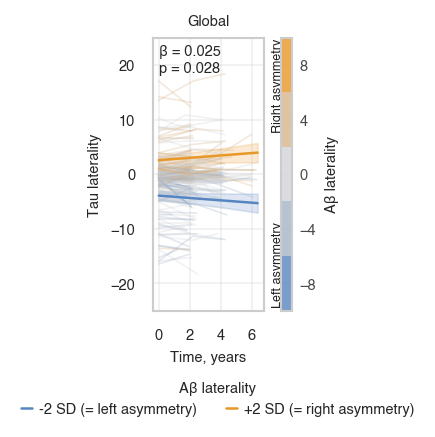

N (A+T-) = 180 (all timepoints = 452)
avg followup years = 2.999
                 Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   tnic_cho_com_I_II_LI
No. Observations:   452       Method:               REML                
No. Groups:         180       Scale:                0.1994              
Min. group size:    2         Log-Likelihood:       -533.1250           
Max. group size:    5         Converged:            Yes                 
Mean group size:    2.5                                                 
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     -0.014    0.106 -0.134 0.894 -0.221  0.193
time                           0.030    0.026  1.150 0.250 -0.021  0.082
age_bas                       -0.013    0.075 -0.176 0.861 -0.161  0.134
gend

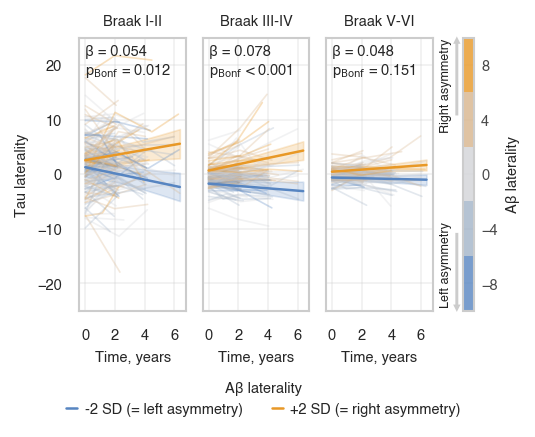

N (A+T+) = 109 (all timepoints = 255)
avg followup years = 2.667
                 Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   tnic_cho_com_I_II_LI
No. Observations:   255       Method:               REML                
No. Groups:         109       Scale:                0.1300              
Min. group size:    2         Log-Likelihood:       -292.6099           
Max. group size:    4         Converged:            Yes                 
Mean group size:    2.3                                                 
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     -0.047    0.121 -0.386 0.700 -0.284  0.190
time                          -0.010    0.036 -0.282 0.778 -0.080  0.060
age_bas                       -0.058    0.089 -0.657 0.511 -0.232  0.116
gend

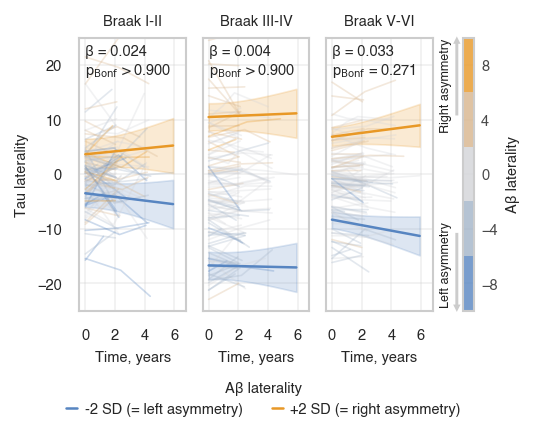

N (A+T- to A+T-) = 142 (all timepoints = 347)
avg followup years = 2.864
                 Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   tnic_cho_com_I_II_LI
No. Observations:   347       Method:               REML                
No. Groups:         142       Scale:                0.2174              
Min. group size:    2         Log-Likelihood:       -414.4307           
Max. group size:    4         Converged:            No                  
Mean group size:    2.4                                                 
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.010    0.121  0.080 0.936 -0.227  0.246
time                           0.036    0.030  1.201 0.230 -0.023  0.096
age_bas                        0.014    0.087  0.161 0.872 -0.157  0.

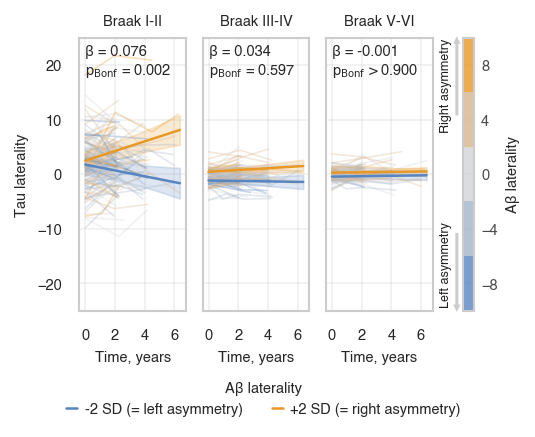

N (A+T- to A+T+) = 38 (all timepoints = 105)
avg followup years = 3.500
                 Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   tnic_cho_com_I_II_LI
No. Observations:   105       Method:               REML                
No. Groups:         38        Scale:                0.1486              
Min. group size:    2         Log-Likelihood:       -124.4198           
Max. group size:    5         Converged:            Yes                 
Mean group size:    2.8                                                 
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     -0.073    0.243 -0.298 0.766 -0.550  0.405
time                          -0.021    0.057 -0.357 0.721 -0.133  0.092
age_bas                       -0.136    0.166 -0.822 0.411 -0.461  0.1

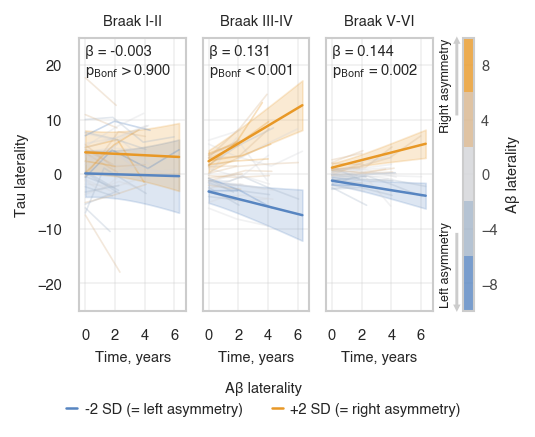

In [5]:
posthoc = True

ROIs_dict = {
    'global': 'Global', 
    'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI',
}

set_plot_style(dpi=150)
statann_kwargs = dict(fontsize=7, color='#494949')
line_kwargs = dict(lw=0.8, alpha=0.3)
colors = ['#5785C1FF', '#A3B4C8', '#D3D4D8FF', '#D8B58C', '#E89826']
cmap = ListedColormap(colors, name="BlueToGrayToOrange")

for grp, grp_data in plots_rois_dict.items():

    df_g = grp_data['df']
    rois_dict = grp_data['rois']

    print(f"N ({grp}) = {len(df_g['mid'].unique())} (all timepoints = {len(df_g)})")

    _w = 110/4.1
    _w_ratio = [*[1] * len(rois_dict), 0.1]

    fig = plt.figure(figsize=(_w*(len(rois_dict)+0.1)/25.4, 60/25.4))
    gs = fig.add_gridspec(1, len(rois_dict)+1, width_ratios=_w_ratio, wspace=0.2)
    axs = []
    for i in range(len(rois_dict)):
        axs.append(fig.add_subplot(gs[0, i]))

    all_stats = {}
    for i, (ROI, ROI_name) in enumerate(rois_dict.items()):
        
        # define the tau and ab columns
        tau_reg = f'{tau_prefix}_{ROI}_LI'
        amy_reg = f'{amy_prefix}_{ROI}_LI'

        df_roi = df_g.copy()

        tau_lim, amy_lim = [-25, 25], [-10, 10]

        df_lme = df_roi[['mid', 'time', 'age_bas', 'gender_baseline_variable', tau_reg, amy_reg]].copy()
        df_lme[f'{amy_reg}_bas'] = df_lme.groupby('mid')[amy_reg].transform(lambda x: x.iloc[0])

        avg_fup = df_lme.groupby('mid')['time'].transform(lambda x: x.iloc[-1:]).mean()
        if i==0: print(f'avg followup years = {avg_fup:.3f}')

        # Store original values before z-scoring
        orig_means = df_lme[['age_bas', f'{tau_reg}', f'{amy_reg}_bas']].mean()
        orig_stds = df_lme[['age_bas', f'{tau_reg}', f'{amy_reg}_bas']].std()

        # Z-score the continuous variables
        cols_to_zscore = ['age_bas', f'{tau_reg}', f'{amy_reg}_bas']
        df_lme_z = df_lme.copy()
        df_lme_z[cols_to_zscore] = df_lme_z[cols_to_zscore].apply(zscore)

        # srcdata_dir = "/Users/to8050an/Documents/phd-neurodegeneration-imaging/projects/01_tau_asymmetry/data/SOURCE_DATA"
        # df_src = df_lme.copy()
        # df_src['anon_ID'] = df_src['mid'].astype('category').cat.codes + 1
        # df_src['group'] = grp
        # df_src[["anon_ID", "group", "time", f"fnc_{ROI}_LI_bas", f"tnic_{ROI}_LI"]].reset_index(drop=True).to_excel(os.path.join(srcdata_dir, f"fig56_{grp}_{ROI}.xlsx"))

        # fit the LME
        formula = f"{tau_reg} ~ time * (age_bas + gender_baseline_variable + {amy_reg}_bas)"
        model = smf.mixedlm(formula, data=df_lme_z, groups="mid", re_formula="~time")
        results = model.fit()

        print(results.summary())
        
        ### plotting

        ax = axs[i]

        # define time range for prediction
        time_min, time_max = df_lme['time'].min(), df_lme['time'].max()
        time_range = np.linspace(time_min, time_max, 100)

        # define two amyloid LI values for prediction
        amy_minmax = [-2*df_lme[f'{amy_reg}_bas'].std(), 2*df_lme[f'{amy_reg}_bas'].std()]
        print(f'-+2SD Ab LI = {amy_minmax}')
        colors = [cmap(0.01), cmap(0.99)]
        labels = [f'-2 SD (= left asymmetry)', f'+2 SD (= right asymmetry)']

        # get covariance matrix of the fixed effects parameters
        fixed_effects_cov = results.cov_params().iloc[:8, :8] #[:6, :6]

        # plot the individual datapoints as spaghetti plot
        for subject in df_lme['mid'].unique():
            subject_data = df_lme[df_lme['mid'] == subject]
            ax.plot(subject_data['time'], subject_data[tau_reg],
                    c=cmap((subject_data[f'{amy_reg}_bas'].mean() - amy_lim[0])/(amy_lim[1] - amy_lim[0])),
                    **line_kwargs)
        
        # plt.ylim([-1.1*df_lme[tau_reg].abs().max(), 1.1*df_lme[tau_reg].abs().max()])
        ax.set_ylim(tau_lim)

        # run prediction with two predefined amyloid LIs
        for amy_val, color, label in zip(amy_minmax, colors, labels):
            # Create prediction data (z-scored)
            temp_data = pd.DataFrame({
                'time': time_range,
                'age_bas': [(df_lme['age_bas'].mean() - orig_means['age_bas'])/orig_stds['age_bas']] * len(time_range),
                'gender_baseline_variable': [df_lme['gender_baseline_variable'].mode()[0]] * len(time_range),
                f'{amy_reg}_bas': [(amy_val - orig_means[f'{amy_reg}_bas'])/orig_stds[f'{amy_reg}_bas']] * len(time_range)
            })

            # Get predictions and transform back to original scale
            pred_mean = results.predict(temp_data)
            pred_mean_orig = pred_mean * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']

            # Calculate confidence intervals
            design_matrix = np.asarray(patsy.dmatrix(formula.split('~')[1], data=temp_data))
            prediction_var = np.diag(design_matrix @ fixed_effects_cov @ design_matrix.T)
            se = np.sqrt(prediction_var)

            # Transform CIs back to original scale
            lower_ci = (pred_mean - 1.96 * se) * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']
            upper_ci = (pred_mean + 1.96 * se) * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']

            # Plot
            ax.plot(time_range, pred_mean_orig, color=color, linewidth=1.2, label=label)
            ax.fill_between(time_range, lower_ci, upper_ci, color=color, alpha=0.2)
        
        if i > 0:
            ax.set_ylabel('')
            ax.set_yticklabels([])
        else:
            ax.set_ylabel('Tau laterality')
        ax.set_title(ROI_name)

        # add annotation of the interaction effect
        interaction_idx = results.model.exog_names.index('time:' + f'{amy_reg}_bas')
        all_stats.update({
            ROI_name: {
                'beta': results.params[interaction_idx],
                'pval': results.pvalues[interaction_idx]
            }
        })

        # last iteration
        if i == len(rois_dict)-1:
            # asymmetry direction arrows
            yrange = tau_lim[1] - tau_lim[0]
            arrowprops_kwargs = dict(arrowstyle='simple', color='#CCCCCC', lw=0.01)
            arrowtext_kwargs = dict(color='#212121', rotation=90, fontsize=6, ha='center', va='center', 
                                    transform=ax.get_yaxis_transform())
            ax.annotate('', xy=(1.225, tau_lim[1] + yrange*0.02), xytext=(1.225, tau_lim[1] - yrange*0.3),
                        xycoords=('axes fraction', 'data'), arrowprops=arrowprops_kwargs)
            ax.text(1.125, tau_lim[1] - yrange*0.175, 'Right asymmetry', **arrowtext_kwargs)
            ax.annotate('', xy=(1.225, tau_lim[0] - yrange*0.02), xytext=(1.225, tau_lim[0] + yrange*0.3),
                        xycoords=('axes fraction', 'data'), arrowprops=arrowprops_kwargs)
            ax.text(1.125, tau_lim[0] + yrange*0.17, 'Left asymmetry', **arrowtext_kwargs)

            # colorbar
            cax = fig.add_subplot(gs[0, -1])
            norm2 = plt.Normalize(amy_lim[0], amy_lim[1])

            colors2 = cmap(np.linspace(0, 1, cmap.N))
            colors2[:, -1] = 0.8#line_kwargs['alpha']  # Set alpha value for all colors
            transparent_cmap = matplotlib.colors.ListedColormap(colors2)
            
            sm = plt.cm.ScalarMappable(cmap=transparent_cmap, norm=norm2)
            cbar = plt.colorbar(sm, cax=cax, label='Aβ laterality')
            # cbar.locator = matplotlib.ticker.MaxNLocator(integer=True)
            cbar.locator = matplotlib.ticker.MultipleLocator(4)
            cbar.update_ticks()
            cbar.ax.tick_params(length=0, color='#CCCCCC', labelcolor='#494949')

            pos = cax.get_position()
            cax.set_position([pos.x0 + 0.028, pos.y0, pos.width, pos.height])
        
        ax.set_xlim([-0.4, 6.8])
        ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
        ax.set_xlabel('Time, years')
        
        if i == 0: handles, labels = ax.get_legend_handles_labels()
    
    # interaction term p-values FDR-corrected (based on the meta-ROIs) and added to plot
    all_pvals = [entry['pval'] for entry in all_stats.values()]
    _, all_pvals_fdr, _, _ = multipletests(all_pvals, method='bonferroni')
    for i, key in enumerate(all_stats.keys()):
        all_stats[key]['pval_fdr'] = all_pvals_fdr[i]
    for i, (ROI, ROI_name) in enumerate(rois_dict.items()):
        ax = axs[i]
        beta = all_stats[ROI_name]['beta']
        pval = all_stats[ROI_name]['pval_fdr']
        if pval < 0.001: ptext = '< 0.001'
        elif pval > 0.9: ptext = '> 0.900'
        else: ptext = f'= {pval:.3f}'
        # ax.text(0.055, 0.975, f'β = {beta:.3f}\np {ptext}',
        #         transform=ax.transAxes, verticalalignment='top')
        
        if len(rois_dict) > 1:
            ax.text(0.055, 0.975, fr'β = {beta:.3f}' + '\np' + r'$_{\mathrm{Bonf}}$ ' + f'{ptext}',
                transform=ax.transAxes, verticalalignment='top')
        else:
            ax.text(0.055, 0.975, f'β = {beta:.3f}\np {ptext}',
                transform=ax.transAxes, verticalalignment='top')
        


    plt.legend(handles, labels, loc='lower center', frameon=False, title='Aβ laterality', title_fontsize=7, ncol=2,
                handlelength=0.75, handletextpad=0.5, labelspacing=0.5, bbox_to_anchor=(0.5, -0.225), bbox_transform=fig.transFigure)

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'LME_tau_ab_laterality_ld_{grp}_{list(rois_dict.keys())}.pdf'), format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    

#### **Results:** Tau asymmetry in relation to cognitive decline

A+ participants showed distinct patterns of cognitive decline based on the degree of tau asymmetry (i.e., absolute laterality index). Higher baseline tau laterality was associated with steeper decline in modified Preclinical Alzheimer Cognitive Composite (mPACC) scores (Fig. 7a; n=259) in Braak III-IV (β=-0.132, 95%CI=[-0.171; -0.094], pBonf<0.001) and V-VI (β=-0.157, 95%CI=[-0.194; -0.121], pBonf<0.001). However, after adjusting for average tau uptake at the corresponding meta-ROIs, the independent effect of tau laterality on mPACC over time was statistically significant only in regions corresponding to Braak V-VI (Fig. 7b; β=-0.104, 95%CI=[-0.153; -0.055], pBonf<0.001). Direction of tau lateralisation (left vs right asymmetry) did not influence cognitive trajectories (see Fig. S2.15 in Supplementary S2). Aβ laterality did not have any significant effect on mPACC scores (Fig. 7c). See Supplementary Table S2.8 for an overview of the models.

1
N (A+) = 289 (all timepoints = 707)
259
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + tnic_cho_com_I_II_LI_bas)
                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      mPACC_v2 
No. Observations:        606          Method:                  REML     
No. Groups:              259          Scale:                   0.1785   
Min. group size:         2            Log-Likelihood:          -689.7751
Max. group size:         4            Converged:               Yes      
Mean group size:         2.3                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.139    0.060  2.292 0.022  0.020  0.257
time                          -0.160    0.029 -5.582 0.000 -0.216 -0.104
age_bas           

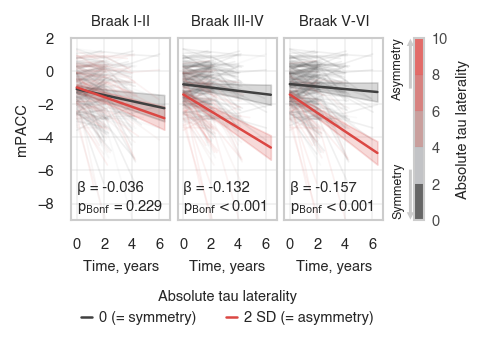

2
N (A+) = 289 (all timepoints = 707)
259
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + tnic_cho_com_I_II_bas + tnic_cho_com_I_II_LI_bas)
                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      mPACC_v2 
No. Observations:        606          Method:                  REML     
No. Groups:              259          Scale:                   0.1922   
Min. group size:         2            Log-Likelihood:          -665.3177
Max. group size:         4            Converged:               Yes      
Mean group size:         2.3                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.154    0.057  2.707 0.007  0.043  0.266
time                          -0.153    0.026 -5.828 0.000 -0.204 -

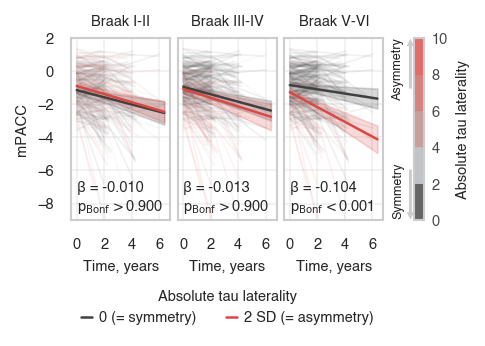

3
N (A+) = 289 (all timepoints = 707)
259
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + fnc_cho_com_I_II_LI_bas)
                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      mPACC_v2 
No. Observations:        606          Method:                  REML     
No. Groups:              259          Scale:                   0.1831   
Min. group size:         2            Log-Likelihood:          -691.4184
Max. group size:         4            Converged:               Yes      
Mean group size:         2.3                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.142    0.060  2.343 0.019  0.023  0.260
time                          -0.161    0.029 -5.615 0.000 -0.217 -0.105
age_bas            

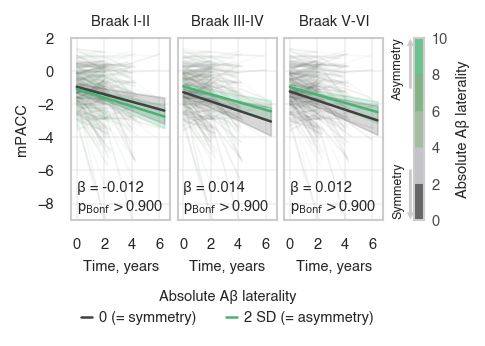

In [6]:
ROIs_dict = {
    'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI',
}

label_dict = {
    'mmse_score': 'MMSE', 'mPACC_v2': 'mPACC', 
}
cogtests = ['mPACC_v2']

set_plot_style(dpi=150)
statann_kwargs = dict(fontsize=7, color='#494949')
line_kwargs = dict(lw=0.8, alpha=0.075)

plots_dict_ = {'A+': df_ld_a}

# for iv_type in [amy_prefix, tau_prefix]:
models_dict = {1: tau_prefix, 2: tau_prefix, 3: amy_prefix}
for m, iv_type in models_dict.items():
    print(m)
    if iv_type == tau_prefix: 
        colors = ['#404040', '#B3B4B8', '#BC8785', '#CE6361', '#DB4743']
        cmap = ListedColormap(colors, name="gray2red")
    elif iv_type == amy_prefix: 
        colors = ['#404040', '#B3B4B8', '#8EAB8C', '#66A167', '#46B370']
        cmap = ListedColormap(colors, name="gray2green")
    for dv in cogtests:
        for grp, df_ in plots_dict_.items():
            print(f"N ({grp}) = {len(df_['mid'].unique())} (all timepoints = {len(df_)})")

            fig = plt.figure(figsize=(72/25.4, 40/25.4))
            gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.1], wspace=0.1)
            axs = []
            for i in range(3):
                axs.append(fig.add_subplot(gs[0, i]))

            all_stats = {}
            for i, (ROI, ROI_name) in enumerate(ROIs_dict.items()):

                if iv_type == amy_prefix:
                    covar_li = f'{tau_prefix}_{ROI}_LI'
                    covar_load = f'{tau_prefix}_{ROI}'
                    iv_label = 'Absolute Aβ laterality'
                    iv_lim = [0, 10]
                elif iv_type == tau_prefix:
                    covar_li = f'{amy_prefix}_{ROI}_LI'
                    covar_load = f'{amy_prefix}_{ROI}'
                    iv_label = 'Absolute tau laterality'
                    iv_lim = [0, 10]
                iv_li = f'{iv_type}_{ROI}_LI'
                iv_load = f'{iv_type}_{ROI}'


                df_roi = df_.copy()

                # Set limits based on DV
                if dv == 'mmse_score': dv_lim = [10, 33]
                if dv == 'mPACC_v2': dv_lim = [-9, 2]

                # Prepare data
                df_lme = df_roi[['mid', 'time', 'age_bas', 'gender_baseline_variable', dv, covar_load, iv_load, covar_li, iv_li]].copy()
                df_lme[f'{iv_li}_bas'] = df_lme.groupby('mid')[iv_li].transform(lambda x: x.iloc[0]).abs()
                df_lme[f'{covar_li}_bas'] = df_lme.groupby('mid')[covar_li].transform(lambda x: x.iloc[0]).abs()
                df_lme[f'{iv_load}_bas'] = df_lme.groupby('mid')[iv_load].transform(lambda x: x.iloc[0])
                df_lme[f'{covar_load}_bas'] = df_lme.groupby('mid')[covar_load].transform(lambda x: x.iloc[0])

                df_lme = df_lme.dropna()
                df_lme = df_lme[df_lme.groupby('mid')['mid'].transform('count') > 1]
                
                if i==0: print(len(df_lme['mid'].unique()))

                # Store original values before z-scoring
                orig_means = df_lme[[dv, 'age_bas', f'{covar_load}_bas', f'{iv_load}_bas', f'{covar_li}_bas', f'{iv_li}_bas']].mean()
                orig_stds = df_lme[[dv, 'age_bas', f'{covar_load}_bas', f'{iv_load}_bas', f'{covar_li}_bas', f'{iv_li}_bas']].std()

                # Z-score the continuous variables
                cols_to_zscore = ['age_bas', dv, f'{covar_load}_bas', f'{iv_load}_bas', f'{covar_li}_bas', f'{iv_li}_bas']
                df_lme_z = df_lme.copy()
                df_lme_z[cols_to_zscore] = df_lme_z[cols_to_zscore].apply(zscore)

                # srcdata_dir = "/Users/to8050an/Documents/phd-neurodegeneration-imaging/projects/01_tau_asymmetry/data/SOURCE_DATA"
                # df_src = df_lme.copy()
                # df_src['anon_ID'] = df_src['mid'].astype('category').cat.codes + 1
                # df_src['group'] = grp
                # df_src[["anon_ID", "group", "time", f"{iv_li}_bas", dv]].reset_index(drop=True).to_excel(os.path.join(srcdata_dir, f"fig7_{grp}_{iv_li}.xlsx"))

                # Fit the model
                # formula = f"{dv} ~ time * (age_bas + gender_baseline_variable + {iv_load}_bas + {covar_li}_bas + {iv_li}_bas)"
                if m == 1: 
                    formula = f"{dv} ~ time * (age_bas + gender_baseline_variable + {iv_li}_bas)"
                    n_cov = 8
                elif m == 2: 
                    formula = f"{dv} ~ time * (age_bas + gender_baseline_variable + {iv_load}_bas + {iv_li}_bas)"
                    n_cov = 10
                elif m == 3: 
                    formula = f"{dv} ~ time * (age_bas + gender_baseline_variable + {iv_li}_bas)"
                    n_cov = 8
                print(formula)
                model = smf.mixedlm(formula, data=df_lme_z, groups="mid", re_formula="~time")
                results = model.fit()

                print(results.summary())

                ax = axs[i]

                # Prediction
                time_min, time_max = df_lme['time'].min(), df_lme['time'].max()
                time_range = np.linspace(time_min, time_max, 100)
                amy_minmax = [0, 2*df_lme[f'{iv_li}_bas'].std()]
                print(f'0 & 2SD {iv_li} = {amy_minmax}')
                # print(amy_minmax)
                colors = [cmap(0.01), cmap(0.99)]
                labels = ['0 (= symmetry)', f'2 SD (= asymmetry)']

                # Plot individual data points (using original scale)
                for subject in df_lme['mid'].unique():
                    subject_data = df_lme[df_lme['mid'] == subject]
                    ax.plot(subject_data['time'], subject_data[dv],
                        # c=cmap((subject_data[f'{iv_li}_bas'].mean() - amy_minmax[0])/(amy_minmax[1] - amy_minmax[0])), # based on the data
                        c=cmap((subject_data[f'{iv_li}_bas'].mean() - iv_lim[0])/(iv_lim[1] - iv_lim[0])), # based on the limits
                        **line_kwargs)

                ax.set_ylim(dv_lim)

                fixed_effects_cov = results.cov_params().iloc[:n_cov, :n_cov]#[:12, :12]

                for amy_val, color, label in zip(amy_minmax, colors, labels):
                    # Create prediction data (z-scored)
                    temp_data = pd.DataFrame({
                        'time': time_range,
                        'age_bas': [(df_lme['age_bas'].mean() - orig_means['age_bas'])/orig_stds['age_bas']] * len(time_range),
                        'gender_baseline_variable': [df_lme['gender_baseline_variable'].mode()[0]] * len(time_range),
                        f'{covar_load}_bas': [(df_lme[f"{covar_load}_bas"].mean() - orig_means[f'{covar_load}_bas'])/orig_stds[f'{covar_load}_bas']] * len(time_range),
                        f'{iv_load}_bas': [(df_lme[f"{iv_load}_bas"].mean() - orig_means[f'{iv_load}_bas'])/orig_stds[f'{iv_load}_bas']] * len(time_range),
                        f'{covar_li}_bas': [(df_lme[f"{covar_li}_bas"].mean() - orig_means[f'{covar_li}_bas'])/orig_stds[f'{covar_li}_bas']] * len(time_range),
                        f'{iv_li}_bas': [(amy_val - orig_means[f'{iv_li}_bas'])/orig_stds[f'{iv_li}_bas']] * len(time_range)
                    })

                    # Get predictions and transform back to original scale
                    pred_mean = results.predict(temp_data)
                    pred_mean_orig = pred_mean * orig_stds[dv] + orig_means[dv]

                    # Calculate confidence intervals
                    design_matrix = np.asarray(patsy.dmatrix(formula.split('~')[1], data=temp_data))
                    prediction_var = np.diag(design_matrix @ fixed_effects_cov @ design_matrix.T)
                    se = np.sqrt(prediction_var)

                    # Transform CIs back to original scale
                    lower_ci = (pred_mean - 1.96 * se) * orig_stds[dv] + orig_means[dv]
                    upper_ci = (pred_mean + 1.96 * se) * orig_stds[dv] + orig_means[dv]

                    # Plot
                    ax.plot(time_range, pred_mean_orig, color=color, linewidth=1.2, label=label)
                    ax.fill_between(time_range, lower_ci, upper_ci, color=color, alpha=0.2)

                # Rest of your plotting code remains the same
                if i > 0:
                    ax.set_ylabel('')
                    ax.set_yticklabels([])
                else:
                    ax.set_ylabel(label_dict[dv])
                ax.set_title(ROI_name)

                # add annotation of the interaction effect
                interaction_idx = results.model.exog_names.index('time:' + f'{iv_li}_bas')
                all_stats.update({
                    ROI_name: {
                        'beta': results.params[interaction_idx],
                        'pval': results.pvalues[interaction_idx]
                    }
                })

                # last iteration
                if i == len(ROIs_dict)-1:
                    # asymmetry direction arrows
                    yrange = dv_lim[1] - dv_lim[0]
                    arrowprops_kwargs = dict(arrowstyle='simple', color='#CCCCCC', lw=0.01)
                    arrowtext_kwargs = dict(color='#212121', rotation=90, fontsize=6, ha='center', va='center', 
                                            transform=ax.get_yaxis_transform())
                    ax.annotate('', xy=(1.275, dv_lim[1] + yrange*0.02), xytext=(1.275, dv_lim[1] - yrange*0.3),
                                xycoords=('axes fraction', 'data'), arrowprops=arrowprops_kwargs)
                    ax.text(1.15, dv_lim[1] - yrange*0.165, 'Asymmetry', **arrowtext_kwargs)
                    ax.annotate('', xy=(1.275, dv_lim[0] - yrange*0.02), xytext=(1.275, dv_lim[0] + yrange*0.3),
                                xycoords=('axes fraction', 'data'), arrowprops=arrowprops_kwargs)
                    ax.text(1.15, dv_lim[0] + yrange*0.165, 'Symmetry', **arrowtext_kwargs)

                    # colorbar
                    cax = fig.add_subplot(gs[0, -1])
                    norm2 = plt.Normalize(iv_lim[0], iv_lim[1]) # based on the limits

                    colors2 = cmap(np.linspace(0, 1, cmap.N))
                    colors2[:, -1] = 0.8#line_kwargs['alpha']  # Set alpha value for all colors
                    transparent_cmap = matplotlib.colors.ListedColormap(colors2)
                    
                    sm = plt.cm.ScalarMappable(cmap=transparent_cmap, norm=norm2)
                    cbar = plt.colorbar(sm, cax=cax, label=iv_label)
                    # cbar.locator = matplotlib.ticker.MaxNLocator(integer=True)
                    # cbar.locator = matplotlib.ticker.MultipleLocator(2)
                    cbar.formatter = matplotlib.ticker.ScalarFormatter(useOffset=False)

                    cbar.update_ticks()
                    cbar.ax.tick_params(length=0, color='#CCCCCC', labelcolor='#494949')

                    pos = cax.get_position()
                    cax.set_position([pos.x0 + 0.055, pos.y0, pos.width, pos.height])
                
                # ax.set_xlim([-0.5, 6.5])
                ax.set_xlim([-0.4, 6.8])
                ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
                ax.set_xlabel('Time, years')
                if i == 1:
                    ax.legend(loc='lower center', frameon=False, title=iv_label, title_fontsize=7, ncol=2,
                            handlelength=0.75, handletextpad=0.5, labelspacing=0.5, bbox_to_anchor=(0.5, -0.65))
            
            # interaction term p-values FDR-corrected (based on the meta-ROIs) and added to plot
            all_pvals = [entry['pval'] for entry in all_stats.values()]
            _, all_pvals_fdr, _, _ = multipletests(all_pvals, method='bonferroni')
            for i, key in enumerate(all_stats.keys()):
                all_stats[key]['pval_b'] = all_pvals_fdr[i]
            for i, (ROI, ROI_name) in enumerate(rois_dict.items()):
                ax = axs[i]
                beta = all_stats[ROI_name]['beta']
                pval = all_stats[ROI_name]['pval_b']
                if pval < 0.001: ptext = '< 0.001'
                elif pval > 0.9: ptext = '> 0.900'
                else: ptext = f'= {pval:.3f}'
                # ax.text(0.055, 0.025, f'β = {beta:.3f}\np {ptext}',
                #         transform=ax.transAxes, verticalalignment='bottom')
                ax.text(0.055, 0.025, fr'β = {beta:.3f}' + '\np' + r'$_{\mathrm{Bonf}}$ ' + f'{ptext}',
                transform=ax.transAxes, verticalalignment='bottom')
                
            plt.tight_layout()
            plt.savefig(os.path.join(plot_dir, f'LME_m{m}_{grp}_{dv}_{iv_type}_LI_ld.pdf'), format='pdf', bbox_inches='tight', dpi=300)
            plt.show()


#### **Supplementary:** Association between tau and Aβ laterality and longitudinal change in tau burden

To assess whether asymmetry in tau or Aβ pathology predicts faster tau accumulation, we fitted
two LME models in the longitudinal Aβ-positive cohort: for tau laterality (LME: tau load ~
time * (agebaseline + sex + Aβ loadbaseline + tau LIbaseline) + [1 + time | participant]) and for Aβ
laterality (LME: tau load ~ time * (agebaseline + sex + Aβ loadbaseline + Aβ LIbaseline) + [1 + time |
participant]), with Bonferroni correction applied to p-values for multiple comparisons across
the meta-ROIs analysed. We found that higher baseline absolute tau laterality predicted faster
tau burden increases in Braak III-IV (β=0.085, pBonf<0.001) and Braak V-VI (β=0.114,
pBonf<0.001) regions but not in Braak I-II (Fig. S2.14a). In contrast, Aβ laterality did not display
any significant effect on longitudinal change in tau burden in any of the meta-ROIs
(all pBonf>0.200; Fig. S2.14b). These results indicate that tau lateralisation is linked to
accelerated pathological disease progression in affected regions, a relationship independent of
Aβ asymmetry.

N (A+) = 289 (all timepoints = 707)
avg followup years = 2.874


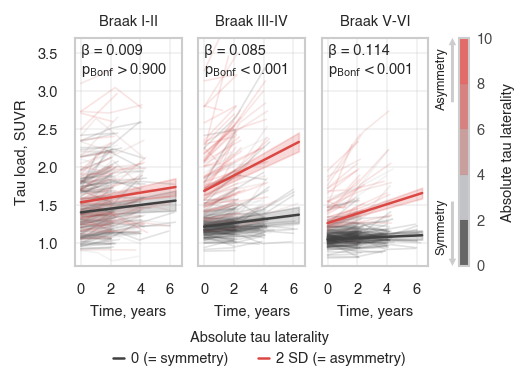

N (A+) = 289 (all timepoints = 707)
avg followup years = 2.874


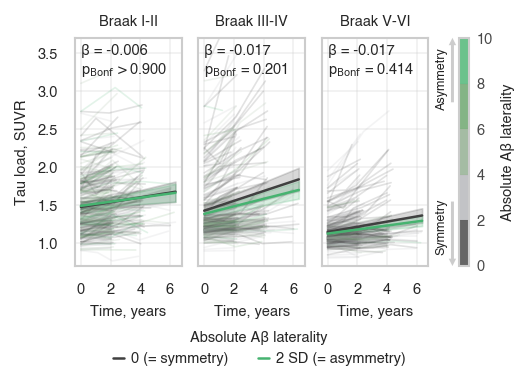

In [7]:
posthoc = True

plots_rois_dict2 = {'A+': {
    'df': df_ld_a, 
    'rois': {
        'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI'
        }
    }
}

ROIs_dict = {
    'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI',
}

l_ivs = ['tau', 'Aβ']

set_plot_style(dpi=150)
statann_kwargs = dict(fontsize=7, color='#494949')
line_kwargs = dict(lw=0.8, alpha=0.15)
# colors = ['#404040', '#B3B4B8', '#8EAB8C', '#66A167', '#46B370']
# cmap = ListedColormap(colors, name="gray2green")

for iv_type in l_ivs:
    if iv_type == 'tau': 
        colors = ['#404040', '#B3B4B8', '#BC8785', '#CE6361', '#DB4743']
        cmap = ListedColormap(colors, name="gray2red")
    elif iv_type == 'Aβ': 
        colors = ['#404040', '#B3B4B8', '#8EAB8C', '#66A167', '#46B370']
        cmap = ListedColormap(colors, name="gray2green")
    for grp, grp_data in plots_rois_dict2.items():

        df_g = grp_data['df']
        rois_dict = grp_data['rois']

        print(f"N ({grp}) = {len(df_g['mid'].unique())} (all timepoints = {len(df_g)})")

        _w = 110/4.1
        _w_ratio = [*[1] * len(rois_dict), 0.1]

        fig = plt.figure(figsize=(_w*(len(rois_dict)+0.1)/25.4, 50/25.4))
        gs = fig.add_gridspec(1, len(rois_dict)+1, width_ratios=_w_ratio, wspace=0.2)
        axs = []
        for i in range(len(rois_dict)):
            axs.append(fig.add_subplot(gs[0, i]))

        all_stats = {}
        for i, (ROI, ROI_name) in enumerate(rois_dict.items()):
            
            # define the tau and ab columns
            tau_reg = f'{tau_prefix}_{ROI}'
            amy_reg = f'{amy_prefix}_{ROI}'

            if iv_type == 'tau':
                iv = f'{tau_reg}_LI'
            elif iv_type == 'Aβ':
                iv = f'{amy_reg}_LI'

            df_roi = df_g.copy()

            tau_lim, iv_lim = [0.7, 3.7], [0, 10]

            df_lme = df_roi[['mid', 'time', 'age_bas', 'gender_baseline_variable', tau_reg, amy_reg, iv]].copy()
            df_lme[f'{amy_reg}_bas'] = df_lme.groupby('mid')[amy_reg].transform(lambda x: x.iloc[0])
            df_lme[f'{iv}_bas'] = df_lme.groupby('mid')[iv].transform(lambda x: x.iloc[0]).abs()

            avg_fup = df_lme.groupby('mid')['time'].transform(lambda x: x.iloc[-1:]).mean()
            if i==0: print(f'avg followup years = {avg_fup:.3f}')

            # Store original values before z-scoring
            orig_means = df_lme[['age_bas', tau_reg, f'{amy_reg}_bas', f'{iv}_bas']].mean()
            orig_stds = df_lme[['age_bas', tau_reg, f'{amy_reg}_bas', f'{iv}_bas']].std()

            # Z-score the continuous variables
            cols_to_zscore = ['age_bas', tau_reg, f'{amy_reg}_bas', f'{iv}_bas']
            df_lme_z = df_lme.copy()
            df_lme_z[cols_to_zscore] = df_lme_z[cols_to_zscore].apply(zscore)

            # fit the LME
            formula = f"{tau_reg} ~ time * (age_bas + gender_baseline_variable + {amy_reg}_bas + {iv}_bas)"
            model = smf.mixedlm(formula, data=df_lme_z, groups="mid", re_formula="~time")
            results = model.fit()

            # print(results.summary())
            
            ### plotting

            ax = axs[i]

            # define time range for prediction
            time_min, time_max = df_lme['time'].min(), df_lme['time'].max()
            time_range = np.linspace(time_min, time_max, 100)

            # define two amyloid LI values for prediction
            amy_minmax = [0, 2*df_lme[f'{iv}_bas'].std()]
            colors = [cmap(0.01), cmap(0.99)]
            labels = [f'0 (= symmetry)', f'2 SD (= asymmetry)']

            # get covariance matrix of the fixed effects parameters
            fixed_effects_cov = results.cov_params().iloc[:10, :10] #[:6, :6]

            # plot the individual datapoints as spaghetti plot
            for subject in df_lme['mid'].unique():
                subject_data = df_lme[df_lme['mid'] == subject]
                ax.plot(subject_data['time'], subject_data[tau_reg],
                        # c=cmap((subject_data[f'{amy_reg}_bas'].mean() - amy_lim[0])/(amy_lim[1] - amy_lim[0])),
                        c=cmap((subject_data[f'{iv}_bas'].mean() - iv_lim[0])/(iv_lim[1] - iv_lim[0])), # based on the limits
                        **line_kwargs)
            
            # plt.ylim([-1.1*df_lme[tau_reg].abs().max(), 1.1*df_lme[tau_reg].abs().max()])
            ax.set_ylim(tau_lim)

            # run prediction with two predefined amyloid LIs
            for amy_val, color, label in zip(amy_minmax, colors, labels):
                # Create prediction data (z-scored)
                temp_data = pd.DataFrame({
                    'time': time_range,
                    'age_bas': [(df_lme['age_bas'].mean() - orig_means['age_bas'])/orig_stds['age_bas']] * len(time_range),
                    'gender_baseline_variable': [df_lme['gender_baseline_variable'].mode()[0]] * len(time_range),
                    f'{amy_reg}_bas': [(df_lme[f'{amy_reg}_bas'].mean() - orig_means[f'{amy_reg}_bas'])/orig_stds[f'{amy_reg}_bas']] * len(time_range),
                    f'{iv}_bas': [(amy_val - orig_means[f'{iv}_bas'])/orig_stds[f'{iv}_bas']] * len(time_range)
                })

                # Get predictions and transform back to original scale
                pred_mean = results.predict(temp_data)
                pred_mean_orig = pred_mean * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']

                # Calculate confidence intervals
                design_matrix = np.asarray(patsy.dmatrix(formula.split('~')[1], data=temp_data))
                prediction_var = np.diag(design_matrix @ fixed_effects_cov @ design_matrix.T)
                se = np.sqrt(prediction_var)

                # Transform CIs back to original scale
                lower_ci = (pred_mean - 1.96 * se) * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']
                upper_ci = (pred_mean + 1.96 * se) * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']

                # Plot
                ax.plot(time_range, pred_mean_orig, color=color, linewidth=1.2, label=label)
                ax.fill_between(time_range, lower_ci, upper_ci, color=color, alpha=0.2)
            
            if i > 0:
                ax.set_ylabel('')
                ax.set_yticklabels([])
            else:
                ax.set_ylabel('Tau load, SUVR')
            ax.set_title(ROI_name)

            # add annotation of the interaction effect
            interaction_idx = results.model.exog_names.index('time:' + f'{iv}_bas')
            all_stats.update({
                ROI_name: {
                    'beta': results.params[interaction_idx],
                    'pval': results.pvalues[interaction_idx]
                }
            })

            # last iteration
            if i == len(rois_dict)-1:
                # asymmetry direction arrows
                yrange = tau_lim[1] - tau_lim[0]
                arrowprops_kwargs = dict(arrowstyle='simple', color='#CCCCCC', lw=0.01)
                arrowtext_kwargs = dict(color='#212121', rotation=90, fontsize=6, ha='center', va='center', 
                                        transform=ax.get_yaxis_transform())
                ax.annotate('', xy=(1.225, tau_lim[1] + yrange*0.02), xytext=(1.225, tau_lim[1] - yrange*0.3),
                            xycoords=('axes fraction', 'data'), arrowprops=arrowprops_kwargs)
                ax.text(1.125, tau_lim[1] - yrange*0.175, 'Asymmetry', **arrowtext_kwargs)
                ax.annotate('', xy=(1.225, tau_lim[0] - yrange*0.02), xytext=(1.225, tau_lim[0] + yrange*0.3),
                            xycoords=('axes fraction', 'data'), arrowprops=arrowprops_kwargs)
                ax.text(1.125, tau_lim[0] + yrange*0.17, 'Symmetry', **arrowtext_kwargs)

                # colorbar
                cax = fig.add_subplot(gs[0, -1])
                norm2 = plt.Normalize(iv_lim[0], iv_lim[1])

                colors2 = cmap(np.linspace(0, 1, cmap.N))
                colors2[:, -1] = 0.8#line_kwargs['alpha']  # Set alpha value for all colors
                transparent_cmap = matplotlib.colors.ListedColormap(colors2)
                
                sm = plt.cm.ScalarMappable(cmap=transparent_cmap, norm=norm2)
                cbar = plt.colorbar(sm, cax=cax, label=f'Absolute {iv_type} laterality')
                cbar.update_ticks()
                cbar.ax.tick_params(length=0, color='#CCCCCC', labelcolor='#494949')

                pos = cax.get_position()
                cax.set_position([pos.x0 + 0.028, pos.y0, pos.width, pos.height])
            
            ax.set_xlim([-0.4, 6.8])
            ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
            ax.set_xlabel('Time, years')
            
            if i == 0: handles, labels = ax.get_legend_handles_labels()
        
        # interaction term p-values FDR-corrected (based on the meta-ROIs) and added to plot
        all_pvals = [entry['pval'] for entry in all_stats.values()]
        _, all_pvals_fdr, _, _ = multipletests(all_pvals, method='bonferroni')
        for i, key in enumerate(all_stats.keys()):
            all_stats[key]['pval_b'] = all_pvals_fdr[i]
        for i, (ROI, ROI_name) in enumerate(rois_dict.items()):
            ax = axs[i]
            beta = all_stats[ROI_name]['beta']
            pval = all_stats[ROI_name]['pval_b']
            if pval < 0.001: ptext = '< 0.001'
            elif pval > 0.9: ptext = '> 0.900'
            else: ptext = f'= {pval:.3f}'
            ax.text(0.055, 0.975, fr'β = {beta:.3f}' + '\np' + r'$_{\mathrm{Bonf}}$ ' + f'{ptext}',
                    transform=ax.transAxes, verticalalignment='top')

        plt.legend(handles, labels, loc='lower center', frameon=False, title=f'Absolute {iv_type} laterality', title_fontsize=7, ncol=2,
                    handlelength=0.75, handletextpad=0.5, labelspacing=0.5, bbox_to_anchor=(0.5, -0.275), bbox_transform=fig.transFigure)

        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, f'LME_ld_{iv_type}_LI_vs_tau_suvr_{grp}_{list(rois_dict.keys())}.pdf'), format='pdf', bbox_inches='tight', dpi=300)
        plt.show()
    

(Reviewer request but not in manuscript) Linear and quadradic mixed effects models at different meta-ROIs displaying change over time in tau laterality)

N (A+) = 289 (all timepoints = 707)
avg followup years = 2.874


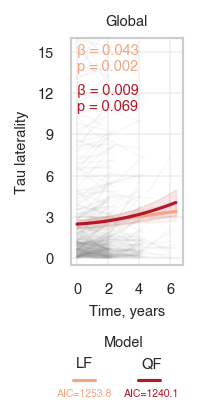

N (A+T-) = 180 (all timepoints = 452)
avg followup years = 2.999


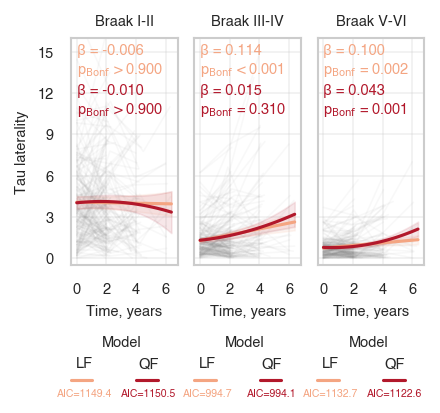

N (A+T+) = 109 (all timepoints = 255)
avg followup years = 2.667


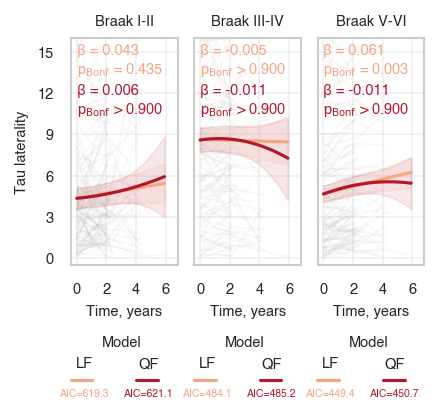

N (A+T- to A+T-) = 142 (all timepoints = 347)
avg followup years = 2.864


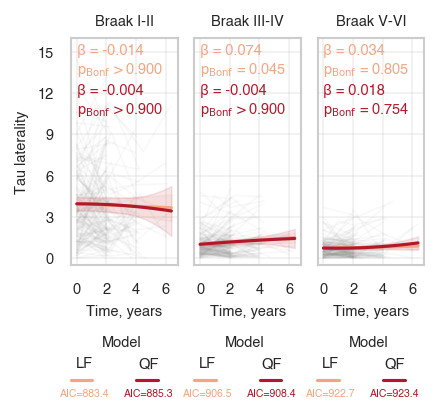

N (A+T- to A+T+) = 38 (all timepoints = 105)
avg followup years = 3.500


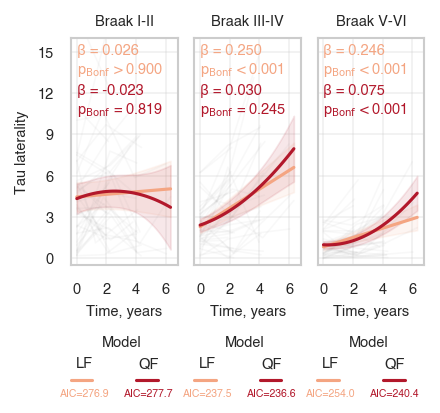

In [8]:
plots_rois_dict_tauonly = {
    'A+': {
        'df': df_ld_a, 
        'rois': {
            'global': 'Global', 
        }
    }
}

set_plot_style(dpi=150)
mdl_plots = {'linear': '#F4A582FF', 'quadratic': '#B2182BFF'}
statann_kwargs = dict(fontsize=7, color='#494949')
line_kwargs = dict(lw=0.8, alpha=0.05, color='gray')

for grp, grp_data in plots_rois_dict.items():

    df_g = grp_data['df']
    rois_dict = grp_data['rois']

    print(f"N ({grp}) = {len(df_g['mid'].unique())} (all timepoints = {len(df_g)})")

    _w = 110/4.1
    _w_ratio = [*[1] * len(rois_dict), 0.1]

    fig = plt.figure(figsize=(_w*(len(rois_dict)+0.1)/25.4, 50/25.4))
    gs = fig.add_gridspec(1, len(rois_dict)+1, width_ratios=_w_ratio, wspace=0.2)
    axs = []
    for i in range(len(rois_dict)):
        axs.append(fig.add_subplot(gs[0, i]))

    for i, (ROI, ROI_name) in enumerate(rois_dict.items()):
        tau_reg = f'{tau_prefix}_{ROI}_LI'

        df_roi = df_g.copy()

        df_lme = df_roi[['mid', 'time', tau_reg]].copy().dropna()
        df_lme[tau_reg] = df_lme[tau_reg].abs()

        avg_fup = df_lme.groupby('mid')['time'].transform(lambda x: x.iloc[-1:]).mean()
        if i==0: print(f'avg followup years = {avg_fup:.3f}')

        # Store original values before z-scoring
        orig_means = df_lme[[f'{tau_reg}']].mean()
        orig_stds = df_lme[[f'{tau_reg}']].std()

        # Z-score the continuous variables
        cols_to_zscore = [f'{tau_reg}']
        df_lme_z = df_lme.copy()
        df_lme_z[cols_to_zscore] = df_lme_z[cols_to_zscore].apply(zscore)

        ### plot datapoints
        ax = axs[i]

        # define time range for prediction
        time_min, time_max = df_lme['time'].min(), df_lme['time'].max()
        time_range = np.linspace(time_min, time_max, 100)

        # plot the individual datapoints as spaghetti plot
        for subject in df_lme['mid'].unique():
            subject_data = df_lme[df_lme['mid'] == subject]
            ax.plot(subject_data['time'], subject_data[tau_reg],
                    **line_kwargs)
        
        #ax.set_ylim(tau_lim)

        temp_data = pd.DataFrame({
            'time': time_range
        })

        # fit linear and quadratic models
        mdls = {}
        for mdl_type, lcolor in mdl_plots.items():
            if mdl_type == 'linear':
                formula = f"{tau_reg} ~ time"
                label = 'LF'
            else:
                formula = f"{tau_reg} ~ time + I(time**2)"
                label = 'QF'
            model = smf.mixedlm(formula, data=df_lme_z, groups="mid", re_formula="~time")
            results = model.fit(reml=False)
            # print(results.summary())
            mdls[mdl_type] = results

            # get covariance matrix of the fixed effects parameters
            if mdl_type == 'linear':
                fixed_effects_cov = results.cov_params().iloc[:2, :2]
            else:
                fixed_effects_cov = results.cov_params().iloc[:3, :3]

            # get predictions and transform back to original scale
            pred_mean = results.predict(temp_data)
            pred_mean_orig = pred_mean * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']

            # calculate confidence intervals
            design_matrix = np.asarray(patsy.dmatrix(formula.split('~')[1], data=temp_data))
            prediction_var = np.diag(design_matrix @ fixed_effects_cov @ design_matrix.T)
            se = np.sqrt(prediction_var)

            # transform CIs back to original scale
            lower_ci = (pred_mean - 1.96 * se) * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']
            upper_ci = (pred_mean + 1.96 * se) * orig_stds[f'{tau_reg}'] + orig_means[f'{tau_reg}']

            # plot
            ax.plot(time_range, pred_mean_orig, color=lcolor, linewidth=1.5, label=label)
            ax.fill_between(time_range, lower_ci, upper_ci, color=lcolor, alpha=0.1)

            # add annotation of the effect size
            if mdl_type == 'linear':
                idx = results.model.exog_names.index('time')
                text_y = 0.975
                lgd_x = 0.125
            elif mdl_type == 'quadratic':
                idx = results.model.exog_names.index('I(time ** 2)')
                text_y = 0.8
                lgd_x = 0.725
            b, p, aic = results.params[idx], results.pvalues[idx], results.aic
            p_c = p * len(rois_dict) # bonf
            if p_c < 0.001: ptext = '< 0.001'
            elif p_c > 0.9: ptext = '> 0.900'
            else: ptext = f'= {p_c:.3f}'

            if len(rois_dict) > 1:
                ax.text(0.055, text_y, fr'β = {b:.3f}' + '\np' + r'$_{\mathrm{Bonf}}$ ' + f'{ptext}',
                    color=lcolor, transform=ax.transAxes, verticalalignment='top')
            else:
                ax.text(0.055, text_y, f'β = {b:.3f}\np {ptext}', color=lcolor,
                    transform=ax.transAxes, verticalalignment='top')
            
            ax.text(lgd_x, -0.45, label, ha='center', transform=ax.transAxes, fontsize=7)
            ax.text(lgd_x, -0.575, f'AIC={aic:.1f}', ha='center', color=lcolor, transform=ax.transAxes, fontsize=5)
            
        if i > 0:
            ax.set_ylabel('')
            ax.set_yticklabels([])
        else:
            ax.set_ylabel('Tau laterality')
        ax.set_title(ROI_name)
        ax.set_xlim([-0.4, 6.8])
        ax.set_ylim([-0.5, 16])
        ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
        ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(3))
        ax.set_xlabel('Time, years')
            
        handles, labels = ax.get_legend_handles_labels()
        # plt.legend(handles, labels, loc='lower center', frameon=False, title='Absolute Aβ laterality', title_fontsize=7, ncol=2,
        #        handlelength=0.75, handletextpad=0.5, labelspacing=0.5, bbox_to_anchor=(0.5, -0.275), bbox_transform=fig.transFigure)
        ax.legend(handles=handles, labels=["", ""], loc='lower center', frameon=False, 
                  title='Model', title_fontsize=7, ncol=2, handlelength=1.5, handletextpad=1, 
                  labelspacing=1.75, bbox_to_anchor=(0.475, -0.6), bbox_transform=ax.transAxes)
    
        
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'LQME_tau_laterality_ld_{grp}_{list(rois_dict.keys())}.pdf'), format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

#### **Supplementary:** Directionality of tau and Aβ laterality and cognition

To assess whether left- or right-predominant pathological asymmetry differentially impacts
cognition, we investigated the effect of baseline tau and Aβ laterality on mPACC scores using
the non-absolute laterality indices (more positive values = more right asymmetry; more
negative values = more left asymmetry). The direction of the tau lateralisation did not lead to
different trajectories of mPACC scores in any regions (Fig. S2.15ab). Similarly, directionality
of Aβ laterality had no effect on cognition (Fig. S2.15c).

1
N (A+) = 289 (all timepoints = 707)
259
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + tnic_cho_com_I_II_LI_bas)
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + tnic_cho_com_III_IV_LI_bas)
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + tnic_cho_com_V_VI_LI_bas)


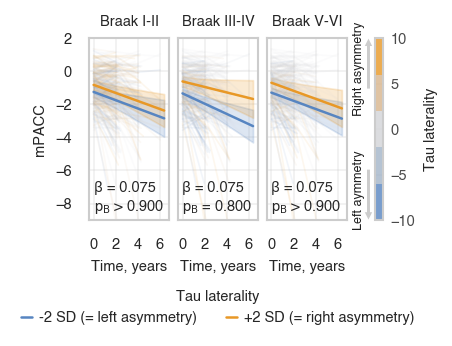

2
N (A+) = 289 (all timepoints = 707)
259
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + tnic_cho_com_I_II_bas + tnic_cho_com_I_II_LI_bas)
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + tnic_cho_com_III_IV_bas + tnic_cho_com_III_IV_LI_bas)
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + tnic_cho_com_V_VI_bas + tnic_cho_com_V_VI_LI_bas)


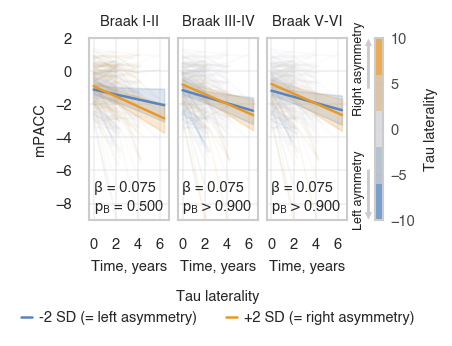

3
N (A+) = 289 (all timepoints = 707)
259
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + fnc_cho_com_I_II_LI_bas)
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + fnc_cho_com_III_IV_LI_bas)
mPACC_v2 ~ time * (age_bas + gender_baseline_variable + fnc_cho_com_V_VI_LI_bas)


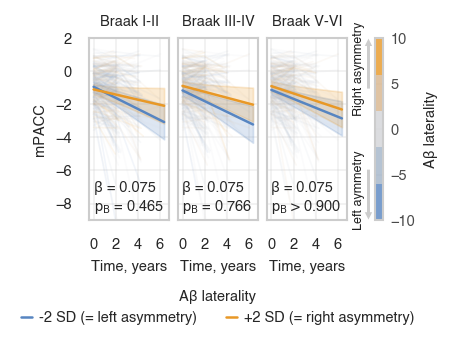

In [9]:
ROIs_dict = {
    'cho_com_I_II': 'Braak I-II', 'cho_com_III_IV': 'Braak III-IV', 'cho_com_V_VI': 'Braak V-VI',
}

label_dict = {
    'mPACC_v2': 'mPACC', 'mmse_score': 'MMSE'
}
cogtests = ['mPACC_v2']

set_plot_style(dpi=150)
statann_kwargs = dict(fontsize=7, color='#494949')
line_kwargs = dict(lw=0.8, alpha=0.075)

plots_dict_ = {'A+': df_ld_a}

# for iv_type in [amy_prefix, tau_prefix]:
models_dict = {1: tau_prefix, 2: tau_prefix, 3: amy_prefix}
for m, iv_type in models_dict.items():
    print(m)
    if iv_type == tau_prefix: 
        colors = ['#5785C1FF', '#A3B4C8', '#D3D4D8FF', '#D8B58C', '#E89826']
        cmap = ListedColormap(colors, name="BlueToGrayToOrange")
    elif iv_type == amy_prefix: 
        colors = ['#5785C1FF', '#A3B4C8', '#D3D4D8FF', '#D8B58C', '#E89826']
        cmap = ListedColormap(colors, name="BlueToGrayToOrange")
    for dv in cogtests:
        for grp, df_ in plots_dict_.items():
            print(f"N ({grp}) = {len(df_['mid'].unique())} (all timepoints = {len(df_)})")

            fig = plt.figure(figsize=(60/25.4, 40/25.4))
            gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.1], wspace=0.15)
            axs = []
            for i in range(3):
                axs.append(fig.add_subplot(gs[0, i]))

            all_stats = {}
            for i, (ROI, ROI_name) in enumerate(ROIs_dict.items()):

                if iv_type == amy_prefix:
                    covar_li = f'{tau_prefix}_{ROI}_LI'
                    covar_load = f'{tau_prefix}_{ROI}'
                    iv_label = 'Aβ laterality'
                    iv_lim = [-10, 10]
                elif iv_type == tau_prefix:
                    covar_li = f'{amy_prefix}_{ROI}_LI'
                    covar_load = f'{amy_prefix}_{ROI}'
                    iv_label = 'Tau laterality'
                    iv_lim = [-10, 10]
                iv_li = f'{iv_type}_{ROI}_LI'
                iv_load = f'{iv_type}_{ROI}'


                df_roi = df_.copy()

                # Set limits based on DV
                if dv == 'mmse_score': dv_lim = [10, 33]
                if dv == 'mPACC_v2': dv_lim = [-9, 2]
                # if dv == 'bnt_15_2': dv_lim = [0, 18]

                # Prepare data
                df_lme = df_roi[['mid', 'time', 'age_bas', 'gender_baseline_variable', dv, covar_load, iv_load, covar_li, iv_li]].copy()
                df_lme[f'{iv_li}_bas'] = df_lme.groupby('mid')[iv_li].transform(lambda x: x.iloc[0])
                df_lme[f'{covar_li}_bas'] = df_lme.groupby('mid')[covar_li].transform(lambda x: x.iloc[0])
                df_lme[f'{iv_load}_bas'] = df_lme.groupby('mid')[iv_load].transform(lambda x: x.iloc[0])
                df_lme[f'{covar_load}_bas'] = df_lme.groupby('mid')[covar_load].transform(lambda x: x.iloc[0])

                df_lme = df_lme.dropna()
                df_lme = df_lme[df_lme.groupby('mid')['mid'].transform('count') > 1]
                
                if i==0: print(len(df_lme['mid'].unique()))

                # Store original values before z-scoring
                orig_means = df_lme[[dv, 'age_bas', f'{covar_load}_bas', f'{iv_load}_bas', f'{covar_li}_bas', f'{iv_li}_bas']].mean()
                orig_stds = df_lme[[dv, 'age_bas', f'{covar_load}_bas', f'{iv_load}_bas', f'{covar_li}_bas', f'{iv_li}_bas']].std()

                # Z-score the continuous variables
                cols_to_zscore = ['age_bas', dv, f'{covar_load}_bas', f'{iv_load}_bas', f'{covar_li}_bas', f'{iv_li}_bas']
                df_lme_z = df_lme.copy()
                df_lme_z[cols_to_zscore] = df_lme_z[cols_to_zscore].apply(zscore)

                # Fit the model
                # formula = f"{dv} ~ time * (age_bas + gender_baseline_variable + {iv_load}_bas + {covar_li}_bas + {iv_li}_bas)"
                if m == 1: 
                    formula = f"{dv} ~ time * (age_bas + gender_baseline_variable + {iv_li}_bas)"
                    n_cov = 8
                elif m == 2: 
                    formula = f"{dv} ~ time * (age_bas + gender_baseline_variable + {iv_load}_bas + {iv_li}_bas)"
                    n_cov = 10
                elif m == 3: 
                    formula = f"{dv} ~ time * (age_bas + gender_baseline_variable + {iv_li}_bas)"
                    n_cov = 8
                print(formula)
                model = smf.mixedlm(formula, data=df_lme_z, groups="mid", re_formula="~time")
                results = model.fit()

                # print(results.summary())

                ax = axs[i]

                # Prediction
                time_min, time_max = df_lme['time'].min(), df_lme['time'].max()
                time_range = np.linspace(time_min, time_max, 100)
                amy_minmax = [-2*df_lme[f'{iv_li}_bas'].std(), 2*df_lme[f'{iv_li}_bas'].std()]
                # print(f'0 & 2SD {iv_li} = {amy_minmax}')
                # print(amy_minmax)
                colors = [cmap(0.01), cmap(0.99)]
                labels = [f'-2 SD (= left asymmetry)', f'+2 SD (= right asymmetry)']

                # Plot individual data points (using original scale)
                for subject in df_lme['mid'].unique():
                    subject_data = df_lme[df_lme['mid'] == subject]
                    ax.plot(subject_data['time'], subject_data[dv],
                        # c=cmap((subject_data[f'{iv_li}_bas'].mean() - amy_minmax[0])/(amy_minmax[1] - amy_minmax[0])), # based on the data
                        c=cmap((subject_data[f'{iv_li}_bas'].mean() - iv_lim[0])/(iv_lim[1] - iv_lim[0])), # based on the limits
                        **line_kwargs)

                ax.set_ylim(dv_lim)

                fixed_effects_cov = results.cov_params().iloc[:n_cov, :n_cov]#[:12, :12]

                for amy_val, color, label in zip(amy_minmax, colors, labels):
                    # Create prediction data (z-scored)
                    temp_data = pd.DataFrame({
                        'time': time_range,
                        'age_bas': [(df_lme['age_bas'].mean() - orig_means['age_bas'])/orig_stds['age_bas']] * len(time_range),
                        'gender_baseline_variable': [df_lme['gender_baseline_variable'].mode()[0]] * len(time_range),
                        f'{covar_load}_bas': [(df_lme[f"{covar_load}_bas"].mean() - orig_means[f'{covar_load}_bas'])/orig_stds[f'{covar_load}_bas']] * len(time_range),
                        f'{iv_load}_bas': [(df_lme[f"{iv_load}_bas"].mean() - orig_means[f'{iv_load}_bas'])/orig_stds[f'{iv_load}_bas']] * len(time_range),
                        f'{covar_li}_bas': [(df_lme[f"{covar_li}_bas"].mean() - orig_means[f'{covar_li}_bas'])/orig_stds[f'{covar_li}_bas']] * len(time_range),
                        f'{iv_li}_bas': [(amy_val - orig_means[f'{iv_li}_bas'])/orig_stds[f'{iv_li}_bas']] * len(time_range)
                    })

                    # Get predictions and transform back to original scale
                    pred_mean = results.predict(temp_data)
                    pred_mean_orig = pred_mean * orig_stds[dv] + orig_means[dv]

                    # Calculate confidence intervals
                    design_matrix = np.asarray(patsy.dmatrix(formula.split('~')[1], data=temp_data))
                    prediction_var = np.diag(design_matrix @ fixed_effects_cov @ design_matrix.T)
                    se = np.sqrt(prediction_var)

                    # Transform CIs back to original scale
                    lower_ci = (pred_mean - 1.96 * se) * orig_stds[dv] + orig_means[dv]
                    upper_ci = (pred_mean + 1.96 * se) * orig_stds[dv] + orig_means[dv]

                    # Plot
                    ax.plot(time_range, pred_mean_orig, color=color, linewidth=1.2, label=label)
                    ax.fill_between(time_range, lower_ci, upper_ci, color=color, alpha=0.2)

                # Rest of your plotting code remains the same
                if i > 0:
                    ax.set_ylabel('')
                    ax.set_yticklabels([])
                else:
                    ax.set_ylabel(label_dict[dv])
                ax.set_title(ROI_name)

                # add annotation of the interaction effect
                interaction_idx = results.model.exog_names.index('time:' + f'{iv_li}_bas')
                all_stats.update({
                    ROI_name: {
                        'beta': results.params[interaction_idx],
                        'pval': results.pvalues[interaction_idx]
                    }
                })

                # last iteration
                if i == len(ROIs_dict)-1:
                    # asymmetry direction arrows
                    yrange = dv_lim[1] - dv_lim[0]
                    arrowprops_kwargs = dict(arrowstyle='simple', color='#CCCCCC', lw=0.01)
                    arrowtext_kwargs = dict(color='#212121', rotation=90, fontsize=6, ha='center', va='center', 
                                            transform=ax.get_yaxis_transform())
                    ax.annotate('', xy=(1.275, dv_lim[1] + yrange*0.02), xytext=(1.275, dv_lim[1] - yrange*0.3),
                                xycoords=('axes fraction', 'data'), arrowprops=arrowprops_kwargs)
                    ax.text(1.15, dv_lim[1] - yrange*0.165, 'Right asymmetry', **arrowtext_kwargs)
                    ax.annotate('', xy=(1.275, dv_lim[0] - yrange*0.02), xytext=(1.275, dv_lim[0] + yrange*0.3),
                                xycoords=('axes fraction', 'data'), arrowprops=arrowprops_kwargs)
                    ax.text(1.15, dv_lim[0] + yrange*0.165, 'Left aymmetry', **arrowtext_kwargs)

                    # colorbar
                    cax = fig.add_subplot(gs[0, -1])
                    norm2 = plt.Normalize(iv_lim[0], iv_lim[1]) # based on the limits

                    colors2 = cmap(np.linspace(0, 1, cmap.N))
                    colors2[:, -1] = 0.8#line_kwargs['alpha']  # Set alpha value for all colors
                    transparent_cmap = matplotlib.colors.ListedColormap(colors2)
                    
                    sm = plt.cm.ScalarMappable(cmap=transparent_cmap, norm=norm2)
                    cbar = plt.colorbar(sm, cax=cax, label=iv_label)
                    # cbar.locator = matplotlib.ticker.MaxNLocator(integer=True)
                    # cbar.locator = matplotlib.ticker.MultipleLocator(2)
                    cbar.formatter = matplotlib.ticker.ScalarFormatter(useOffset=False)

                    cbar.update_ticks()
                    cbar.ax.tick_params(length=0, color='#CCCCCC', labelcolor='#494949')

                    pos = cax.get_position()
                    cax.set_position([pos.x0 + 0.055, pos.y0, pos.width, pos.height])
                
                # ax.set_xlim([-0.5, 6.5])
                ax.set_xlim([-0.4, 6.8])
                ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
                ax.set_xlabel('Time, years')
                if i == 1:
                    ax.legend(loc='lower center', frameon=False, title=iv_label, title_fontsize=7, ncol=2,
                            handlelength=0.75, handletextpad=0.5, labelspacing=0.5, bbox_to_anchor=(0.5, -0.65))
            
            # interaction term p-values FDR-corrected (based on the meta-ROIs) and added to plot
            all_pvals = [entry['pval'] for entry in all_stats.values()]
            _, all_pvals_fdr, _, _ = multipletests(all_pvals, method='bonferroni')
            for i, key in enumerate(all_stats.keys()):
                all_stats[key]['pval_fdr'] = all_pvals_fdr[i]
            for i, (ROI, ROI_name) in enumerate(rois_dict.items()):
                ax = axs[i]
                beta = all_stats[ROI_name]['beta']
                pval = all_stats[ROI_name]['pval_fdr']
                if pval < 0.001: ptext = '< 0.001'
                elif pval > 0.9: ptext = '> 0.900'
                else: ptext = f'= {pval:.3f}'
                # ax.text(0.055, 0.025, f'β = {beta:.3f}\np {ptext}',
                #         transform=ax.transAxes, verticalalignment='bottom')
                ax.text(0.055, 0.025, fr'β = {b:.3f}' + '\np' + r'$_{\mathrm{B}}$ ' + f'{ptext}',
                    transform=ax.transAxes, verticalalignment='bottom')
                
            plt.tight_layout()
            plt.savefig(os.path.join(plot_dir, f'LME_m{m}_{grp}_{dv}_{iv_type}_LI_leftright_ld.pdf'), format='pdf', bbox_inches='tight', dpi=300)
            plt.show()
